In [2]:
!pip install dataretrieval

In [3]:
from dataretrieval import waterdata
import dataretrieval.nwis as nwis
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

Retrieving: continuous · 1 page · 11,407 rows
No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/
Retrieving: continuous · 1 page · 11,415 rows
Retrieving: continuous · 1 page · 11,613 rows
Retrieving: continuous · 1 page · 11,434 rows
Retrieving: continuous · 1 page · 11,179 rows


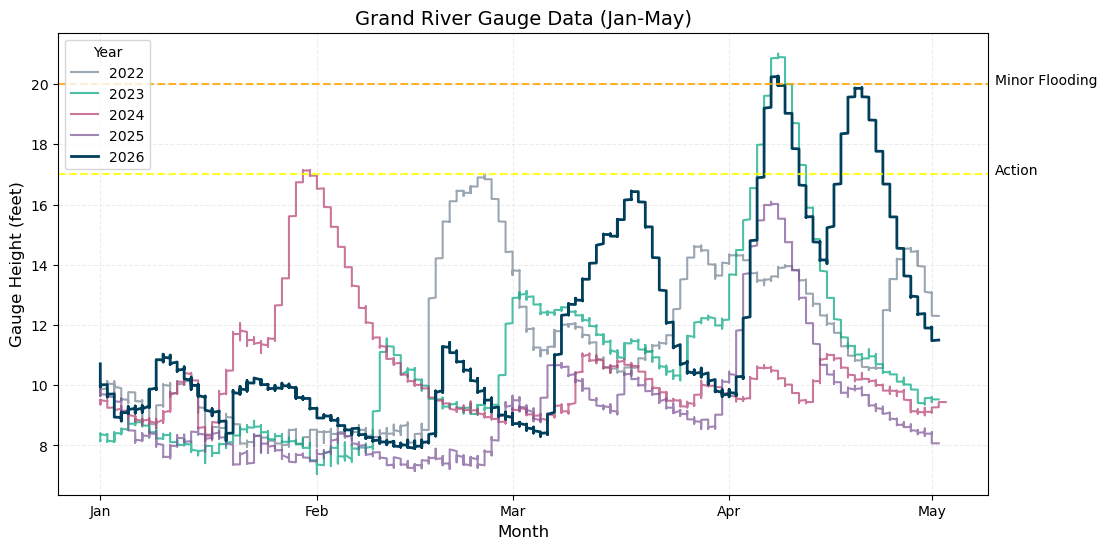

NameError: name 'csv_ready_df' is not defined

In [4]:
site_id = "USGS-04118105"
parameter_code = "00065"
years = [2022,2023,2024,2025,2026]

plt.figure(figsize=(12,6))

colors = {
    2022: "#708090",
    2023: "#00a680",
    2024: "#b53d71",
    2025: "#7a5195",
    2026: "#003f5c",}

for year in years:
    start_date = f"{year}-01-01"
    end_date = f"{year}-05-01"
    df, metadata = waterdata.get_continuous(monitoring_location_id=site_id,parameter_code=parameter_code,
                time=f"{start_date}/{end_date}")
    if df.empty:
        continue
        
    df["time"] = pd.to_datetime(df["time"])
    day_year = df["time"].dt.dayofyear

    if year == 2026:
        plt.plot(day_year, df["value"], label=str(year),linewidth=2, alpha=1, color=colors[year])
    else:
         plt.plot(day_year, df["value"], label=str(year),linewidth=1.5, alpha=0.7, color=colors[year])

plt.axhline(y=17, color='yellow', linestyle='--', linewidth=1.5, alpha=0.85)
plt.axhline(y=20, color='orange', linestyle='--', linewidth=1.5, alpha=0.85)
##plt.axhline(y=21, color='r', linestyle='--', linewidth=1.5, alpha=0.85)

plt.text(y=17,x=129,s="Action", fontsize=10)
plt.text(y=20, x=129, s='Minor Flooding', fontsize=10)

plt.title("Grand River Gauge Data (Jan-May)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Gauge Height (feet)", fontsize=12)
plt.legend(title="Year", loc='upper left')
plt.grid(True,linestyle='--', alpha=0.5, color='gainsboro')

majorticks = [1, 32, 60, 91, 120]
plt.xticks(ticks=majorticks,  labels=['Jan', 'Feb', 'Mar', 'Apr', 'May'])

plt.show()

In [9]:
all_years_data = []

for year in years:
    start_date = f"{year}-01-01"
    end_date = f"{year}-05-01"

    df, metadata = waterdata.get_continuous(
        monitoring_location_id=site_id,
        parameter_code=parameter_code,
        time=f"{start_date}/{end_date}"
)
    
    if df.empty:
        continue
        
    df["time"] = pd.to_datetime(df["time"])

    df_daily = df.groupby(df["time"].dt.date)["value"].max().reset_index()
    df_daily["time"] = pd.to_datetime(df_daily["time"])
    df_daily["Year"] = df_daily["time"].dt.year
    df_daily["Month_Day"] = df_daily["time"].dt.strftime("%m-%d")
    all_years_data.append(df_daily)

master_df = pd.concat(all_years_data, ignore_index=True)
csv_ready_df = master_df.pivot(index="Month_Day", columns="Year", values="value")
csv_ready_df.to_csv("grand_river_gauge_data.csv")

Retrieving: continuous · 1 page · 11,407 rows
Retrieving: continuous · 1 page · 11,415 rows
Retrieving: continuous · 1 page · 11,613 rows
Retrieving: continuous · 1 page · 11,434 rows
Retrieving: continuous · 1 page · 11,179 rows
